<div style="background:linear-gradient(135deg,#0F3D6E 0%,#2176AE 100%);padding:40px 36px 32px 36px;border-radius:10px;margin-bottom:8px;">
  <p style="color:#C8DEF5;font-size:13px;margin:0 0 6px 0;letter-spacing:2px;">CURSO 8 · MÓDULO 1 · CLASE 2</p>
  <h1 style="color:white;font-size:36px;margin:0 0 10px 0;font-weight:700;">Eigenvalues, Matrices Aleatorias y Normal Multivariante</h1>
  <p style="color:#C8DEF5;font-size:16px;margin:0 0 24px 0;font-style:italic;">El puente entre álgebra lineal y probabilidad en regresión</p>
  <hr style="border-color:#5BA4CF;margin:0 0 20px 0;">
  <p style="color:#EAF2FB;font-size:13px;margin:0;">📌 <strong>Docente:</strong> Josef Rodriguez &nbsp;·&nbsp; <strong>Nivel:</strong> Avanzado &nbsp;·&nbsp; <strong>Duración:</strong> 2 horas</p>
</div>

## Objetivos

| # | Al terminar podés |
|---|-------------------|
| 1 | Calcular eigenvalues/eigenvectors e interpretar qué significan |
| 2 | Aplicar eigendecomposición para entender la geometría de XᵀX |
| 3 | Construir vectores y matrices aleatorias con la distribución correcta |
| 4 | Simular datos desde la normal multivariante y verificar sus propiedades |
| 5 | Derivar la distribución de β̂ usando todo lo anterior |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'figure.dpi':110,'font.size':11,
                     'axes.spines.top':False,'axes.spines.right':False})
SEED = 42; np.random.seed(SEED)
print('✅ Setup listo')

✅ Setup listo


---
## 1. Valores y vectores propios (Eigendecomposición)

Para cualquier matriz cuadrada A: **Av = λv**
- **λ** (eigenvalue) = escalar que indica cuánto se estira/comprime en esa dirección
- **v** (eigenvector) = dirección que NO rota, solo se escala

En regresión, los eigenvalues de **XᵀX** miden cuánta información hay en cada dirección del espacio de features.

In [2]:
# Eigendecomposición de una matriz 2×2 — visualizar la geometría
A = np.array([[3, 1],
              [1, 2]], dtype=float)   # simétrica → eigenvectors ortogonales

eigvals, eigvecs = np.linalg.eigh(A)   # eigh: para matrices simétricas (más estable)

print('Matriz A:')
print(A)
print(f'\nEigenvalues  λ = {eigvals}')
print(f'Eigenvectors V =\n{eigvecs}')   # columnas = eigenvectors

# Verificar: Av = λv para cada eigenvector
for i in range(2):
    lam, v = eigvals[i], eigvecs[:, i]
    Av = A @ v
    lv = lam * v
    print(f'\nλ{i+1}={lam:.4f}: Av={Av.round(4)}, λv={lv.round(4)}, iguales={np.allclose(Av,lv)}')

Matriz A:
[[3. 1.]
 [1. 2.]]

Eigenvalues  λ = [1.382 3.618]
Eigenvectors V =
[[ 0.5257 -0.8507]
 [-0.8507 -0.5257]]

λ1=1.3820: Av=[ 0.7265 -1.1756], λv=[ 0.7265 -1.1756], iguales=True

λ2=3.6180: Av=[-3.0777 -1.9021], λv=[-3.0777 -1.9021], iguales=True


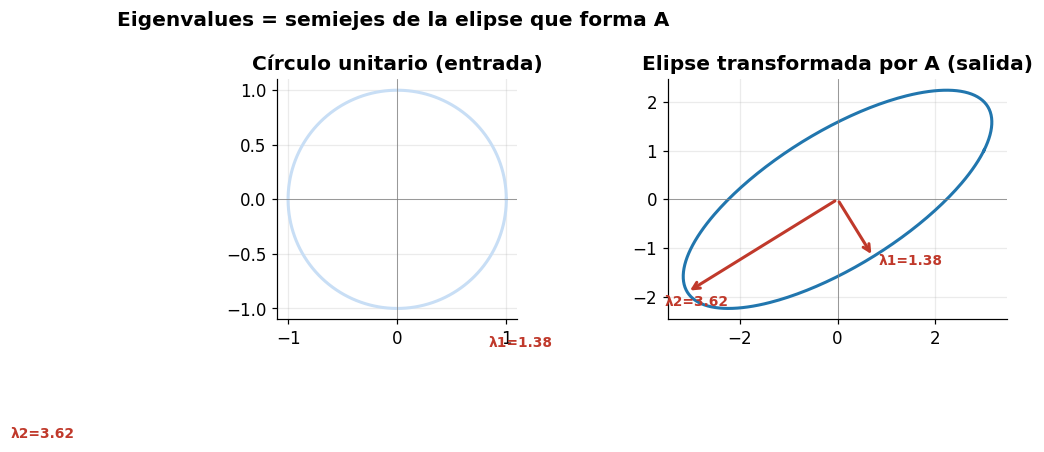

Intuición: los eigenvectors son las direcciones principales de variación.


In [3]:
# Visualizar qué hacen los eigenvectors geométricamente
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

theta = np.linspace(0, 2*np.pi, 300)
circle = np.vstack([np.cos(theta), np.sin(theta)])   # círculo unitario
ellipse = A @ circle                                   # transformar con A

for ax, (data, title, color) in zip(axes, [
    (circle,  'Círculo unitario (entrada)', '#C8DEF5'),
    (ellipse, 'Elipse transformada por A (salida)', '#2176AE')
]):
    ax.plot(data[0], data[1], color=color, lw=2)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.grid(True, alpha=0.25)
    ax.set_title(title, fontweight='bold')

    # Dibujar eigenvectors escalados
    for i in range(2):
        v = eigvecs[:, i] * eigvals[i]
        ax.annotate('', xy=v, xytext=(0,0),
                    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=2))
        ax.text(v[0]*1.15, v[1]*1.15, f'λ{i+1}={eigvals[i]:.2f}',
                fontsize=9, color='#C0392B', fontweight='bold')

plt.suptitle('Eigenvalues = semiejes de la elipse que forma A', fontweight='bold')
plt.tight_layout(); plt.show()
print('Intuición: los eigenvectors son las direcciones principales de variación.')

In [4]:
# Eigendecomposición completa: A = V Λ Vᵀ
A = np.array([[4,2,1],[2,5,3],[1,3,6]], dtype=float)
eigvals, V = np.linalg.eigh(A)
Lambda = np.diag(eigvals)

A_reconstruida = V @ Lambda @ V.T
print('A original:'); print(A)
print('\nV Λ Vᵀ (reconstruida):'); print(A_reconstruida.round(6))
print(f'\n¿A = VΛVᵀ? → {np.allclose(A, A_reconstruida)}')
print(f'\nEigenvalues de A: {eigvals.round(4)}')
print(f'Todos > 0 → def. positiva: {np.all(eigvals > 0)}')
print(f'Determinante = producto de eigenvalues: {np.prod(eigvals):.4f} vs {np.linalg.det(A):.4f}')

A original:
[[4. 2. 1.]
 [2. 5. 3.]
 [1. 3. 6.]]

V Λ Vᵀ (reconstruida):
[[4. 2. 1.]
 [2. 5. 3.]
 [1. 3. 6.]]

¿A = VΛVᵀ? → True

Eigenvalues de A: [1.9213 3.7302 9.3485]
Todos > 0 → def. positiva: True
Determinante = producto de eigenvalues: 67.0000 vs 67.0000


In [5]:
# Eigenvalues de XᵀX: qué nos dicen del dataset
np.random.seed(SEED)
n, p = 200, 4
X_raw = np.random.randn(n, p)
X_raw[:, 3] = X_raw[:, 0] * 0.8 + np.random.randn(n) * 0.3  # correlación alta
X = np.column_stack([np.ones(n), StandardScaler().fit_transform(X_raw)])

XtX = X.T @ X
eigvals_XtX = np.linalg.eigvalsh(XtX)

print('Eigenvalues de XᵀX (de menor a mayor):')
print(eigvals_XtX.round(4))
print(f'\nRatio max/min = {eigvals_XtX.max()/eigvals_XtX.min():.1f}  ← número de condición ≈ este ratio')
print(f'cond(XᵀX)    = {np.linalg.cond(XtX):.1f}')
print('\nEigenvalue pequeño → casi-singularidad en esa dirección → multicolinealidad')

Eigenvalues de XᵀX (de menor a mayor):
[ 13.3177 190.3845 200.     205.1436 391.1542]

Ratio max/min = 29.4  ← número de condición ≈ este ratio
cond(XᵀX)    = 29.4

Eigenvalue pequeño → casi-singularidad en esa dirección → multicolinealidad


---
## 2. Traza y Determinante vía Eigenvalues

Dos atajos muy usados en estadística:
- **tr(A) = Σ λᵢ** — suma de eigenvalues
- **det(A) = Π λᵢ** — producto de eigenvalues

Si algún **λᵢ = 0** → det = 0 → A singular → XᵀX no invertible.

In [6]:
A = np.array([[5,2,1],[2,4,3],[1,3,6]], dtype=float)
eigvals = np.linalg.eigvalsh(A)

print(f'Eigenvalues: {eigvals.round(4)}')
print(f'\ntr(A) directo:            {np.trace(A):.6f}')
print(f'Σ eigenvalues:            {eigvals.sum():.6f}  ← igual ✓')
print(f'\ndet(A) directo:           {np.linalg.det(A):.6f}')
print(f'Π eigenvalues:            {np.prod(eigvals):.6f}  ← igual ✓')

Eigenvalues: [1.4717 4.3845 9.1439]

tr(A) directo:            15.000000
Σ eigenvalues:            15.000000  ← igual ✓

det(A) directo:           59.000000
Π eigenvalues:            59.000000  ← igual ✓


---
## 3. Matrices y Vectores Aleatorios

En estadística, X y y no son fijos — son **realizaciones de variables aleatorias**.

- **E[x]** = vector de esperanzas (media de cada componente)
- **Cov(x) = Σ** = matriz de varianzas-covarianzas
- **Var(xᵢ) = σᵢ²** en la diagonal, **Cov(xᵢ, xⱼ) = σᵢⱼ** fuera de la diagonal

In [7]:
# Vector de esperanzas y matriz de covarianzas empíricas
np.random.seed(SEED)
n_obs = 1000

# Simular 3 variables con covarianzas conocidas
mu_true    = np.array([5.0, -2.0, 8.0])       # medias reales
Sigma_true = np.array([[4.0, 1.5, -0.5],
                        [1.5, 9.0,  2.0],
                        [-0.5, 2.0, 1.0]])     # covarianzas reales

# Generar datos
datos = np.random.multivariate_normal(mu_true, Sigma_true, n_obs)

# Estimar mu y Sigma desde los datos
mu_hat    = datos.mean(axis=0)
Sigma_hat = np.cov(datos, rowvar=False)   # rowvar=False: columnas = variables

print('Vector de medias μ:')
print(f'  Real:     {mu_true}')
print(f'  Estimado: {mu_hat.round(4)}')
print(f'\nMatriz de covarianzas Σ (real vs estimada):')
print('Real:'); print(Sigma_true)
print('Estimada:'); print(Sigma_hat.round(4))

Vector de medias μ:
  Real:     [ 5. -2.  8.]
  Estimado: [ 4.9557 -2.1688  7.9935]

Matriz de covarianzas Σ (real vs estimada):
Real:
[[ 4.   1.5 -0.5]
 [ 1.5  9.   2. ]
 [-0.5  2.   1. ]]
Estimada:
[[ 4.1724  1.6036 -0.4694]
 [ 1.6036  8.3758  1.8369]
 [-0.4694  1.8369  0.9318]]


In [8]:
# Descomponer Σ en correlaciones y desviaciones estándar
stds = np.sqrt(np.diag(Sigma_hat))
D_inv = np.diag(1 / stds)
R = D_inv @ Sigma_hat @ D_inv     # matriz de correlaciones

print('Desviaciones estándar estimadas:', stds.round(4))
print('\nMatriz de correlaciones R:')
print(R.round(4))
print('\nVerificación: diagonal de R = 1:', np.allclose(np.diag(R), 1))

Desviaciones estándar estimadas: [2.0427 2.8941 0.9653]

Matriz de correlaciones R:
[[ 1.      0.2713 -0.2381]
 [ 0.2713  1.      0.6575]
 [-0.2381  0.6575  1.    ]]

Verificación: diagonal de R = 1: True


---
## 4. La Normal Multivariante (MVN)

**x ~ Nₙ(μ, Σ)** es la generalización vectorial de la distribución normal.

$$f(\mathbf{x}) = \frac{1}{(2\pi)^{n/2}|\Sigma|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x}-\boldsymbol{\mu})^\top \Sigma^{-1}(\mathbf{x}-\boldsymbol{\mu})\right)$$

**Propiedades clave:**
- Combinaciones lineales de una MVN son normales
- Si Σ es diagonal → las variables son **independientes**
- Los contornos de probabilidad constante son **elipses** (en 2D)

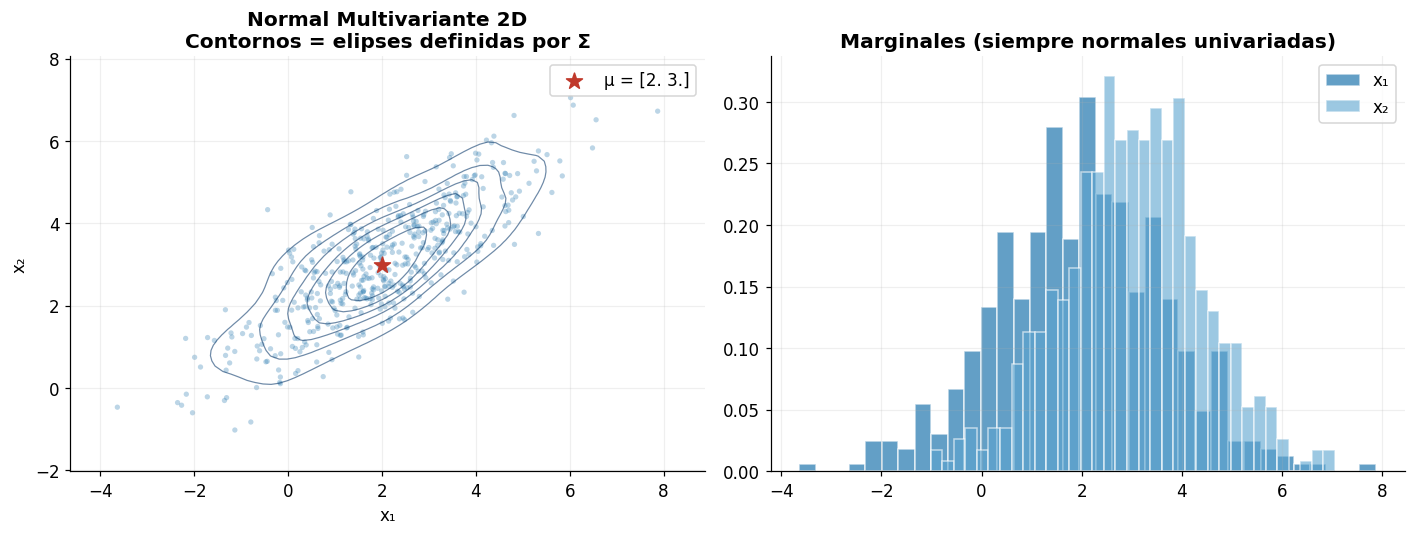

Propiedad clave: cada marginal es N(μᵢ, σᵢᵢ). Los contornos son elipses.


In [9]:
# Visualizar la MVN en 2D: contornos y muestras
np.random.seed(SEED)
mu2    = np.array([2.0, 3.0])
Sigma2 = np.array([[3.0, 2.0],
                    [2.0, 2.0]])

muestras = np.random.multivariate_normal(mu2, Sigma2, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: scatter + contornos
axes[0].scatter(muestras[:,0], muestras[:,1], alpha=0.3, s=12,
                color='#2176AE', edgecolors='none')
axes[0].scatter(*mu2, color='#C0392B', s=120, zorder=5, marker='*',
                label=f'μ = {mu2}')

# Curvas de nivel usando KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(muestras.T)
xg = np.linspace(muestras[:,0].min()-1, muestras[:,0].max()+1, 80)
yg = np.linspace(muestras[:,1].min()-1, muestras[:,1].max()+1, 80)
Xg, Yg = np.meshgrid(xg, yg)
Zg = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)
axes[0].contour(Xg, Yg, Zg, levels=6, colors='#0F3D6E', alpha=0.6, linewidths=0.8)
axes[0].set_title('Normal Multivariante 2D\nContornos = elipses definidas por Σ', fontweight='bold')
axes[0].legend(); axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')
axes[0].grid(True, alpha=0.2)

# Panel derecho: marginales
axes[1].hist(muestras[:,0], bins=35, alpha=0.7, color='#2176AE',
             edgecolor='white', density=True, label='x₁')
axes[1].hist(muestras[:,1], bins=35, alpha=0.6, color='#5BA4CF',
             edgecolor='white', density=True, label='x₂')
axes[1].set_title('Marginales (siempre normales univariadas)', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.2)

plt.tight_layout(); plt.show()
print('Propiedad clave: cada marginal es N(μᵢ, σᵢᵢ). Los contornos son elipses.')

In [10]:
# Propiedades de combinaciones lineales
# Si x ~ N(μ, Σ), entonces Ax + b ~ N(Aμ + b, AΣAᵀ)
np.random.seed(SEED)
x_samples = np.random.multivariate_normal(mu2, Sigma2, 10000)

A_lin = np.array([[1, 2]])   # combinación lineal: y = x₁ + 2x₂
b_lin = np.array([1.0])

y_samples = (x_samples @ A_lin.T + b_lin).ravel()

mu_y_teorico    = (A_lin @ mu2 + b_lin).ravel()[0]
sigma2_y_teorico = (A_lin @ Sigma2 @ A_lin.T).ravel()[0]

print('Transformación lineal: y = x₁ + 2x₂ + 1')
print(f'\nMedia teórica:      {mu_y_teorico:.4f}')
print(f'Media empírica:     {y_samples.mean():.4f}')
print(f'\nVarianza teórica:   {sigma2_y_teorico:.4f}')
print(f'Varianza empírica:  {y_samples.var():.4f}')

# Test de normalidad
_, p_val = stats.shapiro(y_samples[:5000])
print(f'\nTest de normalidad (Shapiro-Wilk): p={p_val:.4f} → normal: {p_val > 0.05}')

Transformación lineal: y = x₁ + 2x₂ + 1

Media teórica:      9.0000
Media empírica:     8.9895

Varianza teórica:   19.0000
Varianza empírica:  19.4297

Test de normalidad (Shapiro-Wilk): p=0.6744 → normal: True


---
## 5. Distribución de β̂ — El resultado central

Bajo el modelo **y = Xβ + ε** con **ε ~ N(0, σ²I)**:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$$

Como es una transformación lineal de y (que es normal):

$$\hat{\boldsymbol{\beta}} \sim \mathcal{N}_p\left(\boldsymbol{\beta},\ \sigma^2(\mathbf{X}^\top\mathbf{X})^{-1}\right)$$

Esto nos da **inferencia**: intervalos de confianza, tests de hipótesis.

In [11]:
# Simular la distribución de β̂ empíricamente
np.random.seed(SEED)
n_sim, n_obs, p = 2000, 80, 3
beta_true  = np.array([3.0, 1.5, -2.0])
sigma2_eps = 1.5 ** 2

# Diseño fijo
X_fijo = np.column_stack([
    np.ones(n_obs),
    np.random.randn(n_obs),
    np.random.randn(n_obs)
])
XtX_inv = np.linalg.inv(X_fijo.T @ X_fijo)

# Distribución teórica de β̂
Cov_beta = sigma2_eps * XtX_inv
print('Covarianza teórica de β̂:')
print(Cov_beta.round(4))
print(f'\nErrores estándar teóricos de cada β̂ᵢ: {np.sqrt(np.diag(Cov_beta)).round(4)}')

# Simular 2000 veces
beta_hats = np.zeros((n_sim, p))
for s in range(n_sim):
    eps = np.random.normal(0, np.sqrt(sigma2_eps), n_obs)
    y_s = X_fijo @ beta_true + eps
    beta_hats[s] = np.linalg.lstsq(X_fijo, y_s, rcond=None)[0]

print('\nErroes estándar empíricos de β̂:')
print(beta_hats.std(axis=0).round(4))
print('\n¿Coinciden teórico vs empírico?',
      np.allclose(np.sqrt(np.diag(Cov_beta)), beta_hats.std(axis=0), rtol=0.05))

Covarianza teórica de β̂:
[[0.0286 0.0039 0.0004]
 [0.0039 0.0311 0.0004]
 [0.0004 0.0004 0.0338]]

Errores estándar teóricos de cada β̂ᵢ: [0.1691 0.1763 0.1839]

Erroes estándar empíricos de β̂:
[0.1679 0.1788 0.1872]

¿Coinciden teórico vs empírico? True


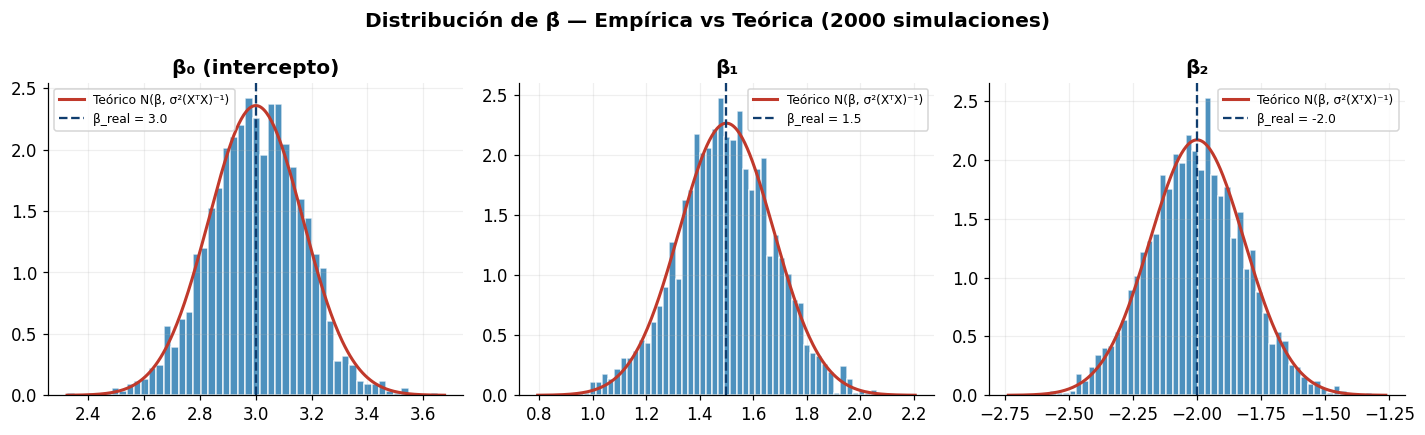

In [12]:
# Visualizar la distribución de β̂
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

labels = ['β₀ (intercepto)', 'β₁', 'β₂']
for i, ax in enumerate(axes):
    ax.hist(beta_hats[:, i], bins=50, density=True,
            color='#2176AE', edgecolor='white', alpha=0.8)

    # Superponer la densidad teórica N(β, σ²(XᵀX)⁻¹)
    mu_t  = beta_true[i]
    std_t = np.sqrt(Cov_beta[i, i])
    xr    = np.linspace(mu_t - 4*std_t, mu_t + 4*std_t, 300)
    ax.plot(xr, stats.norm.pdf(xr, mu_t, std_t),
            color='#C0392B', lw=2, label='Teórico N(β, σ²(XᵀX)⁻¹)')
    ax.axvline(beta_true[i], color='#0F3D6E', lw=1.5, linestyle='--',
               label=f'β_real = {beta_true[i]}')
    ax.set_title(labels[i], fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

plt.suptitle('Distribución de β̂ — Empírica vs Teórica (2000 simulaciones)',
             fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. Aplicación: Entender la Varianza de β̂ en Datos Reales

La varianza de β̂ depende de σ² y de (XᵀX)⁻¹. Vemos cómo cambia con n y con la correlación entre features.

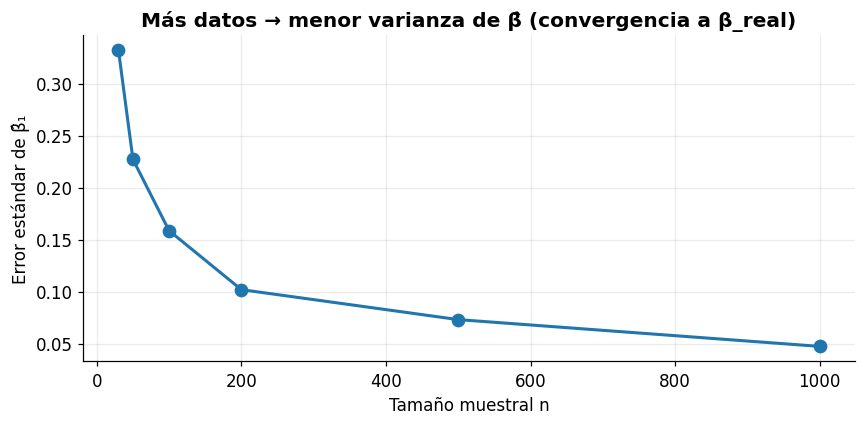

Regla: duplicar n reduce el error estándar en un factor ≈ √2.


In [13]:
# Impacto del tamaño muestral n sobre la precisión de β̂
np.random.seed(SEED)
ns = [30, 50, 100, 200, 500, 1000]
errs = []
for n_i in ns:
    X_i = np.column_stack([np.ones(n_i), np.random.randn(n_i, 2)])
    XtX_i = X_i.T @ X_i
    se_i  = np.sqrt(sigma2_eps * np.diag(np.linalg.inv(XtX_i)))
    errs.append(se_i[1])  # error estándar de β₁

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ns, errs, 'o-', color='#2176AE', lw=2, markersize=8)
ax.set_xlabel('Tamaño muestral n')
ax.set_ylabel('Error estándar de β̂₁')
ax.set_title('Más datos → menor varianza de β̂ (convergencia a β_real)', fontweight='bold')
ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()
print('Regla: duplicar n reduce el error estándar en un factor ≈ √2.')

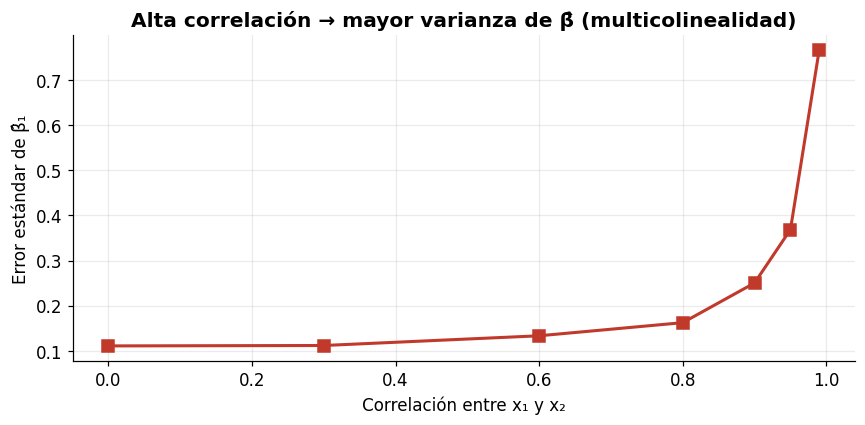

Con ρ=0.99, el error estándar explota — los coeficientes son muy inciertos.


In [14]:
# Impacto de la correlación entre features
np.random.seed(SEED)
n_corr = 200
correlaciones = [0.0, 0.3, 0.6, 0.8, 0.9, 0.95, 0.99]
se_beta1 = []

for rho in correlaciones:
    Sigma_c = np.array([[1, rho], [rho, 1]])
    X_c_raw = np.random.multivariate_normal([0,0], Sigma_c, n_corr)
    X_c = np.column_stack([np.ones(n_corr), X_c_raw])
    try:
        se = np.sqrt(sigma2_eps * np.diag(np.linalg.inv(X_c.T @ X_c)))
        se_beta1.append(se[1])
    except:
        se_beta1.append(np.nan)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(correlaciones, se_beta1, 's-', color='#C0392B', lw=2, markersize=8)
ax.set_xlabel('Correlación entre x₁ y x₂')
ax.set_ylabel('Error estándar de β̂₁')
ax.set_title('Alta correlación → mayor varianza de β̂ (multicolinealidad)', fontweight='bold')
ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()
print('Con ρ=0.99, el error estándar explota — los coeficientes son muy inciertos.')

---
## Conclusiones

<div style="background:#EAF2FB;border-left:5px solid #2176AE;padding:20px 24px;border-radius:0 8px 8px 0;">

**01 · Los eigenvalues de XᵀX lo dicen todo**  
Un eigenvalue cercano a 0 → esa dirección tiene casi-multicolinealidad. El ratio max/min ≈ número de condición.

**02 · β̂ es una variable aleatoria normal**  
β̂ ~ N(β, σ²(XᵀX)⁻¹). Esta distribución es la base de toda la inferencia: t-tests, F-tests, intervalos de confianza.

**03 · Más n, menos correlación → menor varianza de β̂**  
Dos palancas para mejorar la precisión: recolectar más datos y elegir features poco correlacionadas.

</div>

---
**Próxima clase:** Supuestos Gauss-Markov · Propiedad BLUE de β̂ · Formulación completa de OLS

<div style="background:#0F3D6E;color:white;padding:20px 24px;border-radius:8px;">
<strong>Próxima clase — Viernes</strong><br>
Supuestos Gauss-Markov · Estimación de parámetros · Propiedad BLUE · Insesgadez de β̂<br>
<em>Docente: Josef Rodriguez · Curso 8 · Modelos Estadísticos</em>
</div>